# Central Limit Theorem (CLT) - Superstore Dataset

 The objective of this notebook is to understand the Central Limit Theorem (CLT) using the Superstore dataset. I use random sampling to estimate the average sales, compare sample and population means, calculate the Standard Error and 95% Confidence Interval

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Superstore.csv',encoding='latin1')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
sales = df['Sales']

In [7]:
sales.head()

0    261.9600
1    731.9400
2     14.6200
3    957.5775
4     22.3680
Name: Sales, dtype: float64

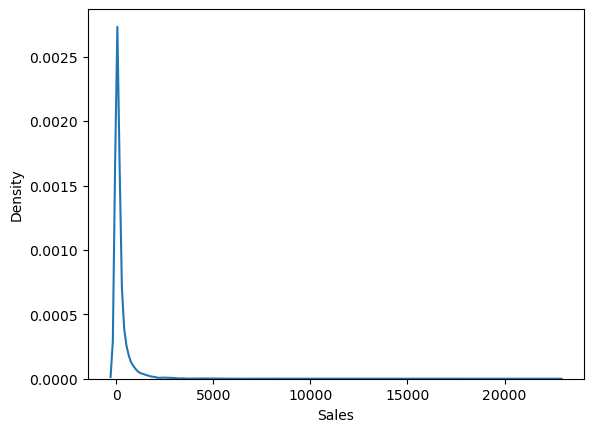

In [9]:
sns.kdeplot(sales)
plt.show()

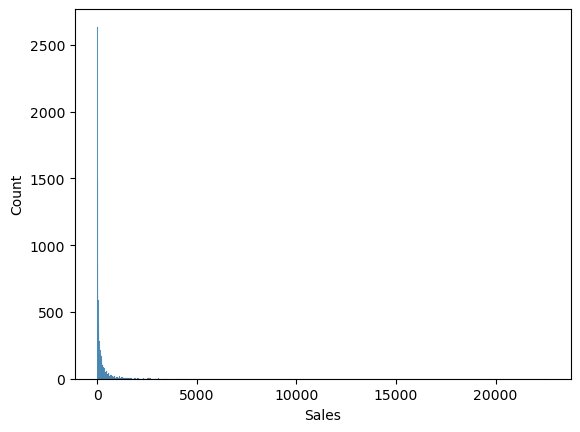

In [10]:
sns.histplot(sales)
plt.show()

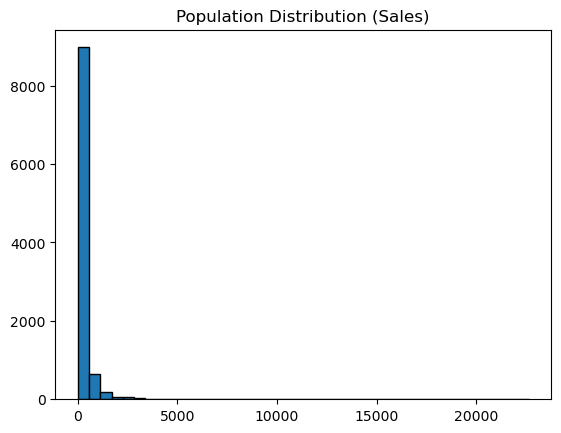

In [12]:
plt.hist(sales, bins=40, edgecolor='black')
plt.title("Population Distribution (Sales)")
plt.show()

# 

### Central Limit Theorem 

In [13]:
sample_size = 30

In [15]:
sample_means = []
for i in range(1000):
    sample_means.append((sales.sample(sample_size)).mean())

In [17]:
sample_means = np.array(sample_means)

In [19]:
sample_means.shape

(1000,)

#### Sampling Distribution

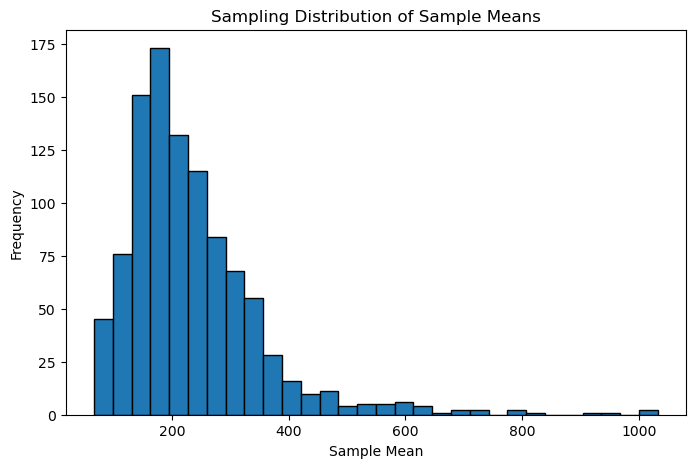

In [29]:
plt.figure(figsize=(8,5))
plt.hist(sample_means, bins=30, edgecolor='black')
plt.title("Sampling Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

<Axes: ylabel='Density'>

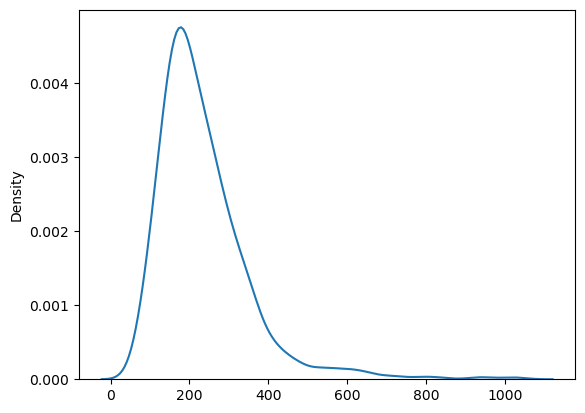

In [30]:
sns.kdeplot(sample_means)

##### Compare Means

In [32]:
print("\nPopulation Mean       :", round(sales.mean(),2))
print("Average Sample Means  :", round(sample_means.mean(),2))


Population Mean       : 229.86
Average Sample Means  : 234.78


# 

##### Standard Error

In [36]:
sample_std = sample_means.std()

In [37]:
SE = sample_std / np.sqrt(sample_size)

In [35]:
print("\nStandard Error :", round(SE,4))


Standard Error : 21.5505


# 

##### 95% Confidence Interval

In [77]:
lower = sample_means.mean() - 2 * SE
upper = sample_means.mean() + 2 * SE

In [78]:
print("\n95% Confidence Interval")
print(f"{lower:.2f} - {upper:.2f}")


95% Confidence Interval
223.42 - 246.14


In [79]:
sales.mean()

np.float64(229.85800083049833)

# 

#####  Sample Size Increases

In [80]:
new_sample_size =100

In [81]:
nw_sample=[]
for i in range(1000):
    nw_sample.append((sales.sample(new_sample_size)).mean())

In [82]:
nw_sample = np.array(nw_sample)

In [83]:
nw_sample.mean()

np.float64(231.423106174)

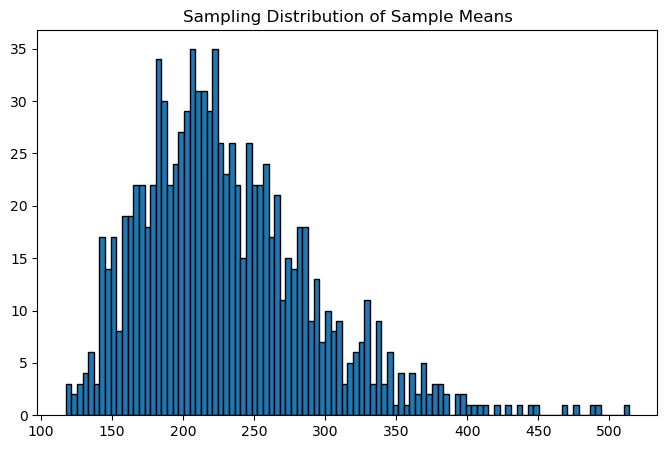

In [84]:
plt.figure(figsize=(8,5))
plt.hist(nw_sample, bins=100, edgecolor='black')
plt.title("Sampling Distribution of Sample Means")
plt.show()

<Axes: ylabel='Density'>

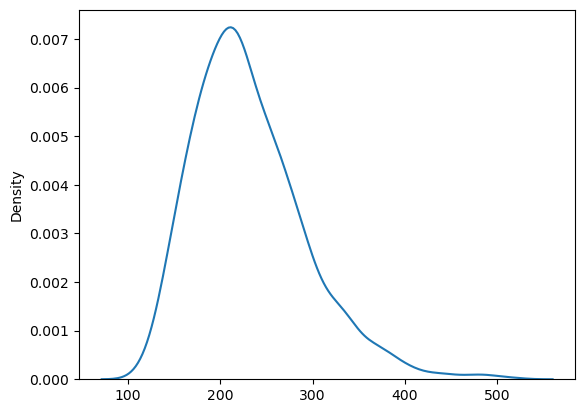

In [85]:
sns.kdeplot(nw_sample)

# 

In [87]:
std2 = nw_sample.std()
lower2 = nw_sample.mean() - 2 *(std2/np.sqrt(new_sample_size))
upper2 = nw_sample.mean() + 2 *(std2/np.sqrt(new_sample_size))

In [88]:
print("\n95% Confidence Interval")
print(f"{lower2:.2f} - {upper2:.2f}")


95% Confidence Interval
219.25 - 243.60


In [92]:
print(sales.mean()) # Population Mean
print(nw_sample.mean()) # sample mean with sample size = 100
print(sample_means.mean()) # sample mean with sample size = 30

229.85800083049833
231.423106174
234.77808035333334


- As the sample size increases, the sample mean becomes closer to the population mean.

# 

##### What Happens When the Sample Size is Less Than 30?

In [93]:
sz=15

In [102]:
sm_sample= []
for i in range(1000):
    sm_sample.append((sales.sample(sz)).mean())

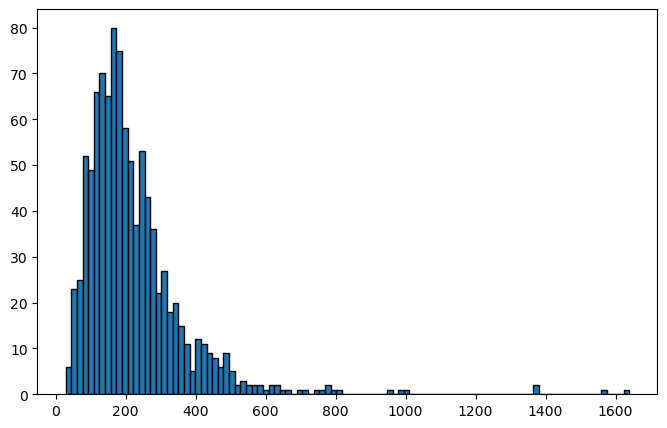

In [103]:
plt.figure(figsize=(8,5))
plt.hist(sm_sample, bins=100, edgecolor='black')
plt.show()

In [104]:
np.array(sm_sample).mean()

np.float64(222.93335004666667)

In [105]:
sales.mean()

np.float64(229.85800083049833)

- A small sample size may not represent the population accurately.
- when sample is small then the data may not be normally distributed,